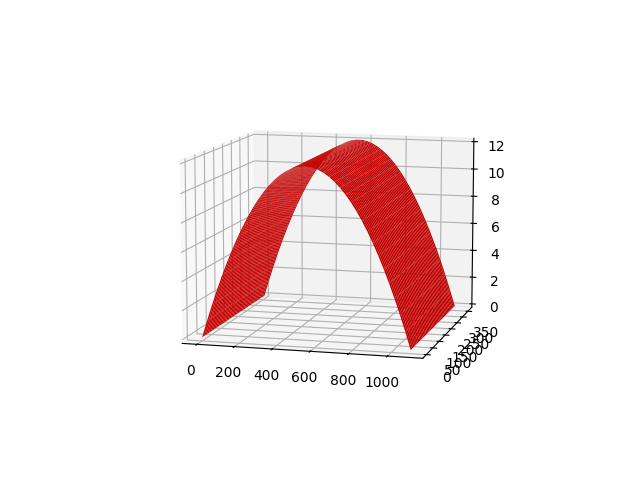

In [ ]:
%matplotlib widget

import matplotlib.pyplot as plt
import numpy as np

#Maße in Millimeter
l = 1100
b = 360
t = 3.8
step = 50

c = 12    #höhe in der mitte
a = c/((l/2)**2)

def f(x,y): # c - a * (x-l/2)²  
    """
    diese Funktion bestimmt die Verwerfung der gemessenen Glasplatte
    Achtung nicht zu verwechseln mit der rechten Seite 'f', aus der Thematik der PDEs, (bei uns die Eigenlast 'q')!
    """
    return c - a * (x-l/2)**2 

#erzeugt gitter für gewünschte werte
x_points = np.linspace(0,l, step)
y_points = np.linspace(0,b, step)
X, Y = np.meshgrid(x_points, y_points)

#speichert (x,y,z) in startwerte_matrix für alle (x,y) in X,Y
startwerte_matrix = np.zeros((step, step),dtype=object)
for i in range(step):
    for j in range(step):
        startwerte_matrix[i, j] = (float(X[i,j]), float(Y[i,j]), float(f(X[i, j], Y[i, j])) )     

# STARTWERTE-Matrix
filename_startwerte = f"{t}mm_startwerte.xyz"

with open(filename_startwerte, "w") as f:
    for i in range(step):
        for j in range(step):
            x, y, w = startwerte_matrix[i, j]
            f.write(f"{x:.6f}\t{y:.6f}\t{w:.6e}\n")

#region PLOTTEN
np.set_printoptions(threshold=np.inf)
data1 = np.loadtxt(filename_startwerte)

x1= data1[:,0]
y1= data1[:,1]
z1= data1[:,2]

# Raster erzeugen
X = np.unique(x1)
Y = np.unique(y1)

X, Y = np.meshgrid(X, Y)
Z1=z1.reshape(len(Y), len(X))


fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.plot_surface(X, Y,Z1,color="red")        

ax.view_init(elev=10, azim=-75)
plt.show()
#endregion